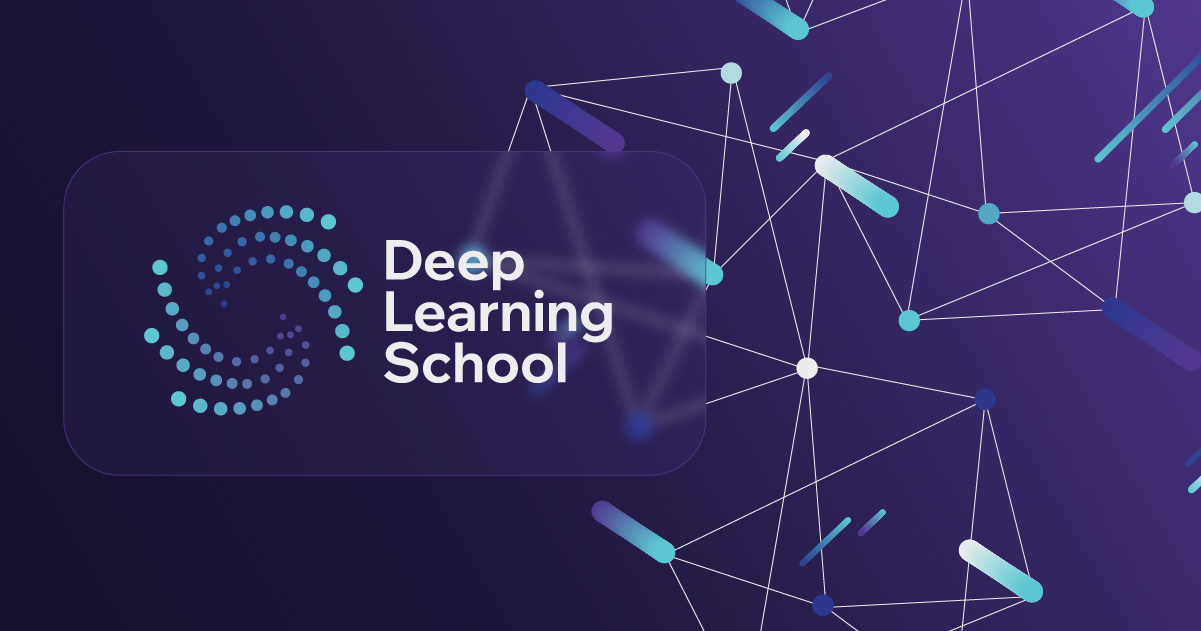

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

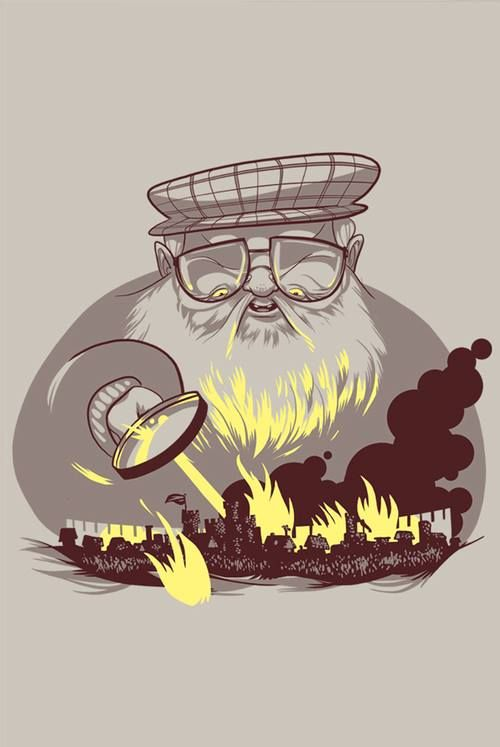

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.75$ --- 5 баллов

2) $0.75 > score \geqslant 0.65$ --- 4 балла

3) $0.65 > score \geqslant 0.55$ --- 3 балла

4) $0.55 > score \geqslant 0.50$ --- 2 балла

5) $0.50 > score \geqslant 0.45$ --- 1 балл

6) $0.45 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [890]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

zsh:1: command not found: gdown
zsh:1: command not found: gdown


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [891]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [892]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')

In [893]:
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [894]:
data.isna().sum()

name                   0
title                840
male                   0
culture             1069
dateOfBirth         1278
mother              1539
father              1535
heir                1536
house                381
spouse              1357
book1                  0
book2                  0
book3                  0
book4                  0
book5                  0
isAliveMother       1539
isAliveFather       1535
isAliveHeir         1536
isAliveSpouse       1357
isMarried              0
isNoble                0
age                 1278
numDeadRelations       0
popularity             0
isAlive                0
dtype: int64

In [895]:
object_col = data.loc[:, data.dtypes == np.object_].columns
num_col = data.loc[:, data.dtypes != np.object_].columns

data[object_col].describe()

,name,title,culture,mother,father,heir,house,spouse
count,1557,717,488,18,22,21,1176,200
unique,1557,195,51,16,19,20,315,186
top,Viserys II Targaryen,Ser,Northmen,Rhaenyra Targaryen,Daemon Targaryen,Jaehaerys Targaryen,House Frey,Walder Frey
freq,1,306,94,2,2,2,89,6


In [896]:
# Предположим, что если нет ииформации о супруге, то этот человек такового не имеет

data['spouse'] = data['spouse'].fillna('No')
data['spouse'].value_counts()

spouse
No                     1357
Walder Frey               6
Craster                   4
Viserys I Targaryen       2
Kiera of Tyrosh           2
                       ... 
Hosteen Frey              1
Jyanna Frey               1
Leobald Tallhart          1
Lorra Royce               1
Davos Seaworth            1
Name: count, Length: 187, dtype: int64

In [897]:
data['isAliveSpouse'] = data['isAliveSpouse'].fillna('No')
data['isAliveSpouse'].value_counts()

isAliveSpouse
No     1357
1.0     158
0.0      42
Name: count, dtype: int64

In [898]:
# аналогично поступим с принадлежностью к дому

data['house'] = data['house'].fillna('No')
data.isna().sum()

name                   0
title                840
male                   0
culture             1069
dateOfBirth         1278
mother              1539
father              1535
heir                1536
house                  0
spouse                 0
book1                  0
book2                  0
book3                  0
book4                  0
book5                  0
isAliveMother       1539
isAliveFather       1535
isAliveHeir         1536
isAliveSpouse          0
isMarried              0
isNoble                0
age                 1278
numDeadRelations       0
popularity             0
isAlive                0
dtype: int64

In [899]:
# запомним возраст медианой
median_age = round(data['age'].mean())
data['age'] = data['age'].fillna(median_age)
data.isna().sum()

name                   0
title                840
male                   0
culture             1069
dateOfBirth         1278
mother              1539
father              1535
heir                1536
house                  0
spouse                 0
book1                  0
book2                  0
book3                  0
book4                  0
book5                  0
isAliveMother       1539
isAliveFather       1535
isAliveHeir         1536
isAliveSpouse          0
isMarried              0
isNoble                0
age                    0
numDeadRelations       0
popularity             0
isAlive                0
dtype: int64

In [900]:
# Заполним пропуски в фиче title и culture

data['title'] = data['title'].fillna('No')
data['culture'] = data['culture'].fillna('No')


In [901]:
data['dateOfBirth'] = data['dateOfBirth'].fillna(-1)
data['mother'] = data['mother'].fillna('No')
data['father'] = data['father'].fillna('No')
data['heir'] = data['heir'].fillna('No')
data['isAliveMother'] = data['isAliveMother'].fillna('No')
data['isAliveFather'] = data['isAliveFather'].fillna('No')
data['isAliveHeir'] = data['isAliveHeir'].fillna('No')


In [902]:
data.isna().sum()

name                0
title               0
male                0
culture             0
dateOfBirth         0
mother              0
father              0
heir                0
house               0
spouse              0
book1               0
book2               0
book3               0
book4               0
book5               0
isAliveMother       0
isAliveFather       0
isAliveHeir         0
isAliveSpouse       0
isMarried           0
isNoble             0
age                 0
numDeadRelations    0
popularity          0
isAlive             0
dtype: int64

**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [903]:
data['isPopular'] = data['popularity'].apply(lambda x: 1 if x >= 0.5 else 0) 
data['boolDeadRelations'] = data['numDeadRelations'].apply(lambda x: 1 if x != 0 else 0)
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive,isPopular,boolDeadRelations
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,No,1,No,-1.0,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,No,No,...,0.0,No,0,0,35.0,11,0.605351,0,1,1
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,No,No,No,House Frey,Perra Royce,...,No,1.0,1,1,97.0,1,0.896321,1,1,1
3,Addison Hill,Ser,1,No,-1.0,No,No,No,House Swyft,No,...,No,No,0,1,35.0,0,0.267559,1,0,0
4,Aemma Arryn,Queen,0,No,82.0,No,No,No,House Arryn,Viserys I Targaryen,...,No,0.0,1,1,23.0,0,0.183946,0,0,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,No,No,No,House Santagar,Eldon Estermont,...,No,1.0,1,1,29.0,0,0.043478,1,0,0


In [904]:
data['culture'].value_counts().shape

(52,)

In [905]:
# Подсказка
cult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
}

In [906]:
for param in cult.keys():
    data['culture'] = data['culture'].apply(lambda x: param if x in cult[param] else x)

In [907]:
data['culture'].value_counts().shape

(49,)

In [908]:
data['age'].value_counts()

age
35.0     1280
100.0      20
19.0       12
15.0       11
20.0       11
         ... 
2.0         1
3.0         1
59.0        1
29.0        1
77.0        1
Name: count, Length: 72, dtype: int64

In [909]:
# # # Добавим призак - это разница между возрастом и годом рождения 

data['delta_age_with_bd'] = np.array((data['age'] + data['dateOfBirth']) == 305) #305 - последний наблюдаемый год

data['book_sum'] = data['book1'] + data['book2']+ data['book3'] + data['book4'] + data['book5']


**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

In [910]:
data.drop(columns=['popularity', 'numDeadRelations', 'title', 'culture', 'name', 'mother',
          'father', 'heir', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'dateOfBirth', 'age', 'book3', 'spouse', 'book2', 'book4'], inplace=True)

In [911]:
data.head()

,male,house,book1,book5,isAliveSpouse,isMarried,isNoble,isAlive,isPopular,boolDeadRelations,delta_age_with_bd,book_sum
S.No,,,,,,,,,,,,
1,1,No,0,0,No,0,0,0,1,1,False,0
2,1,House Frey,1,1,1.0,1,1,1,1,1,True,5
3,1,House Swyft,0,0,No,0,1,1,0,0,False,1
4,0,House Arryn,0,0,0.0,1,1,0,0,0,False,0
5,0,House Santagar,0,0,1.0,1,1,1,0,0,True,1


**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

In [912]:
data['isAlive'].value_counts() 
# переменная является количественной - бинарный признак, данные несбалансированные

isAlive
1    1212
0     345
Name: count, dtype: int64

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [913]:
object_col = data.loc[:, data.dtypes == np.object_].columns
num_col = data.loc[:, data.dtypes != np.object_].columns

In [914]:
data.head()

,male,house,book1,book5,isAliveSpouse,isMarried,isNoble,isAlive,isPopular,boolDeadRelations,delta_age_with_bd,book_sum
S.No,,,,,,,,,,,,
1,1,No,0,0,No,0,0,0,1,1,False,0
2,1,House Frey,1,1,1.0,1,1,1,1,1,True,5
3,1,House Swyft,0,0,No,0,1,1,0,0,False,1
4,0,House Arryn,0,0,0.0,1,1,0,0,0,False,0
5,0,House Santagar,0,0,1.0,1,1,1,0,0,True,1


In [915]:
df = data.copy()

In [916]:
### Секретные функции для фильтрации признаков

def get_redundant_pairs(df):
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

print("Top Absolute Correlations")
print(get_top_abs_correlations(df[num_col], 50))

Top Absolute Correlations
book5              book_sum             0.616283
isPopular          boolDeadRelations    0.545175
book1              book_sum             0.451108
delta_age_with_bd  book_sum             0.315616
isAlive            delta_age_with_bd    0.198311
isMarried          boolDeadRelations    0.197150
                   book_sum             0.187220
book1              book5                0.180542
isAlive            boolDeadRelations    0.178177
male               isAlive              0.148290
book1              boolDeadRelations    0.139291
male               isNoble              0.133807
isMarried          isNoble              0.132037
isAlive            isPopular            0.118673
book1              isAlive              0.112468
book5              delta_age_with_bd    0.094544
male               isMarried            0.094385
book5              boolDeadRelations    0.094381
boolDeadRelations  book_sum             0.088370
isNoble            delta_age_with_bd    0.0

In [917]:
### Сворованный со stackoverflow код
### Удалим колонки, где корреляция оказывается > 0.6

def correlation(dataset, threshold):
    col_corr = set() # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i, j] >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colname = corr_matrix.columns[i] # getting the name of column
                col_corr.add(colname)
                if colname in dataset.columns:
                    del dataset[colname] # deleting the column from the dataset
    
correlation(df[num_col], 0.5)

In [918]:
### Преобразуем категориальные колонки

for col in object_col:
    if col != 'timestamp': 
        if data[col].nunique() < 10:
            one_hot = pd.get_dummies(data[col], prefix=col, drop_first=True)
            data = pd.concat((data.drop(col, axis=1), one_hot), axis=1)

        else:
            mean_target = data.groupby(col)['boolDeadRelations'].mean()
            data[col] = data[col].map(mean_target)

In [919]:
data.head()

,male,house,book1,book5,isMarried,isNoble,isAlive,isPopular,boolDeadRelations,delta_age_with_bd,book_sum,isAliveSpouse_1.0,isAliveSpouse_No
S.No,,,,,,,,,,,,,
1,1,0.049869,0,0,0,0,0,1,1,False,0,False,True
2,1,0.033708,1,1,1,1,1,1,1,True,5,True,False
3,1,0.000000,0,0,0,1,1,0,0,False,1,False,True
4,0,0.181818,0,0,1,1,0,0,0,False,0,False,False
5,0,0.000000,0,0,1,1,1,0,0,True,1,True,False


**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

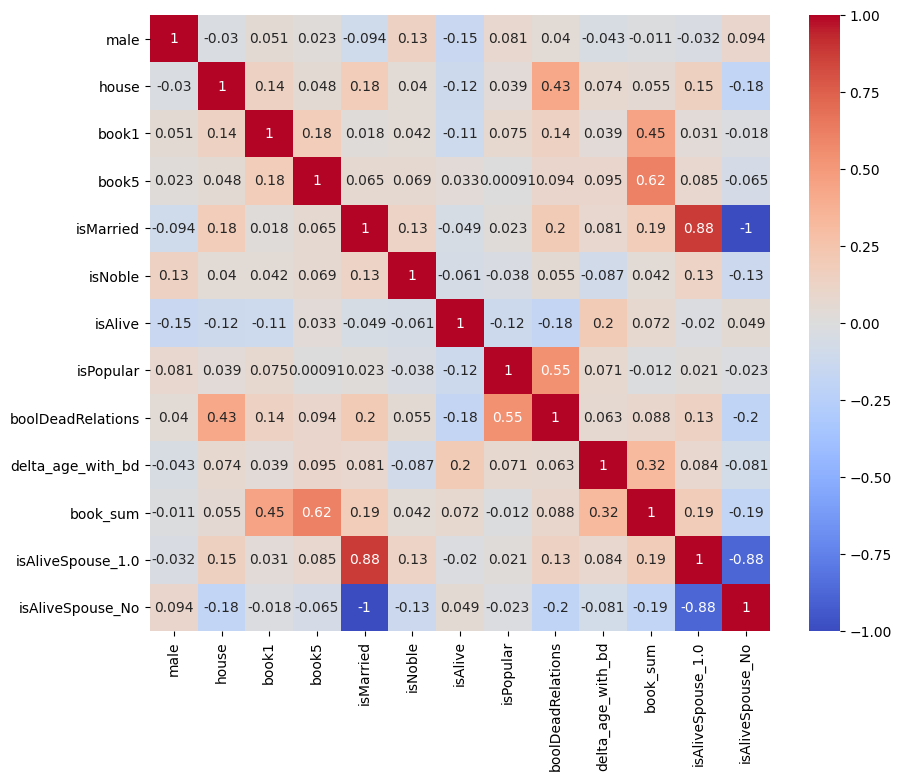

In [920]:
correlation_matrix = data.corr()


fig = plt.figure(figsize=(10, 8))
# Визуализация корреляционной матрицы
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()



In [921]:
data.drop(['isAliveSpouse_1.0', 'isAliveSpouse_No'], axis=1, inplace=True)

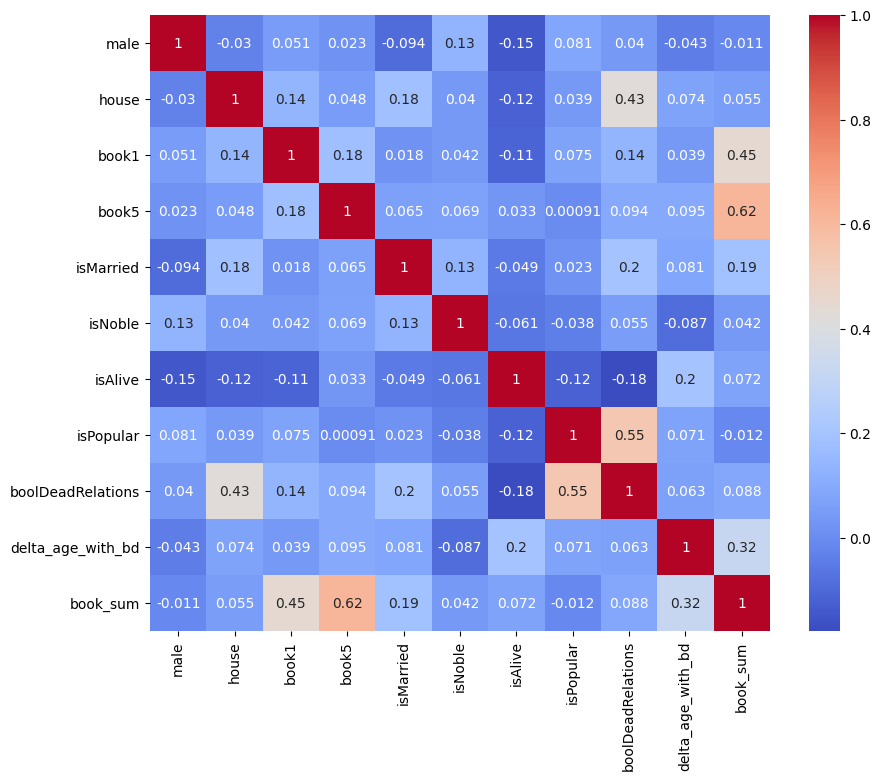

In [941]:
correlation_matrix = data.corr()


fig = plt.figure(figsize=(10, 8))
# Визуализация корреляционной матрицы
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()



**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [922]:
X = data.drop(['isAlive'], axis=1)
y = data['isAlive']

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [923]:
from sklearn.model_selection import train_test_split

In [924]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=2022)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [925]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [926]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [927]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1, penalty='l2')

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

print(f'Accuracy на тесте = {logistic_regression.score(X_test, y_test):.3f} и на трейне = {logistic_regression.score(X_train, y_train):.3f}')

Accuracy на тесте = 0.785 и на трейне = 0.801


Аналогичным образом обучите остальные модели и сделайте предсказания на тестовой выборке.

In [928]:
# Шаг 1. создание модели
random_tree = RandomForestClassifier(n_jobs=-1, n_estimators=100, max_depth=5, min_samples_split=2, random_state=42)

# Шаг 2. обучение модели
random_tree.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
print(f'{random_tree.score(X_test, y_test):.3f}')

0.811


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

model = RandomForestClassifier()

param_grid = {
    'n_estimators': [50, 100, 200],  # Количество деревьев
    'max_depth': [None, 5, 10, 15],  # Максимальная глубина деревьев
    'min_samples_split': [2, 5, 10],  # Минимальное количество образцов для разбиения
    'min_samples_leaf': [1, 2, 4],    # Минимальное количество образцов в листе
    'max_features': ['auto', 'sqrt']   # Максимальное количество признаков
}

# Настройка GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1, verbose=2)

# 6. Обучение модели
grid_search.fit(X_train, y_train)

# Получение лучших параметров
best_params = grid_search.best_params_
print(f'Лучшие параметры: {best_params}')

# Оценка модели на тестовых данных
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Вывод результатов
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')

In [ ]:
grid_search.best_params_

In [931]:
from sklearn.metrics import accuracy_score
model = RandomForestClassifier(max_depth=10, max_features='sqrt', min_samples_leaf=2, min_samples_split=5, n_estimators=100)
model.fit(X_train, y_train)

print(f'{accuracy_score(y_test, model.predict(X_test)):.4f}')

0.7853


## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [932]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Аналогичным образом посчитайте метрику accuracy для остальных моделей

In [ ]:
# Шаг 3. Предсказание на тестовых данных
y_pred = random_tree.predict(X_test)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

Выберите лучшую модель.

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [935]:
# для упрощения жизни напишем функцию, которая сразу будет приводить датасет в нужный вид

def createdata(test_data: pd.DataFrame) -> pd.DataFrame:
    test_data['spouse'] = test_data['spouse'].fillna('No')
    test_data['isAliveSpouse'] = test_data['isAliveSpouse'].fillna('No')
    test_data['house'] = test_data['house'].fillna('No')

    # запомним возраст медианой
    median_age = round(test_data['age'].mean())
    test_data['age'] = test_data['age'].fillna(median_age)
    # Заполним пропуски в фиче title и culture
    test_data['title'] = test_data['title'].fillna('No')
    test_data['culture'] = test_data['culture'].fillna('No')
    test_data['dateOfBirth'] = test_data['dateOfBirth'].fillna(-1)
    test_data['mother'] = test_data['mother'].fillna('No')
    test_data['father'] = test_data['father'].fillna('No')
    test_data['heir'] = test_data['heir'].fillna('No')
    test_data['isAliveMother'] = test_data['isAliveMother'].fillna('No')
    test_data['isAliveFather'] = test_data['isAliveFather'].fillna('No')
    test_data['isAliveHeir'] = test_data['isAliveHeir'].fillna('No')

    test_data['isPopular'] = test_data['popularity'].apply(lambda x: 1 if x >= 0.5 else 0) 
    test_data['boolDeadRelations'] = test_data['numDeadRelations'].apply(lambda x: 1 if x != 0 else 0)

    test_data['delta_age_with_bd'] = np.array((test_data['age'] + test_data['dateOfBirth']) == 305) #305 - последний наблюдаемый год
    test_data['book_sum'] = test_data['book1'] + test_data['book2']+ test_data['book3'] + test_data['book4'] + test_data['book5']

    cult = {
        'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
        'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
        'Asshai': ["asshai'i", 'asshai'],
        'Lysene': ['lysene', 'lyseni'],
        'Andal': ['andal', 'andals'],
        'Braavosi': ['braavosi', 'braavos'],
        'Dornish': ['dornishmen', 'dorne', 'dornish'],
        'Myrish': ['myr', 'myrish', 'myrmen'],
        'Westermen': ['westermen', 'westerman', 'westerlands'],
        'Westerosi': ['westeros', 'westerosi'],
        'Stormlander': ['stormlands', 'stormlander'],
        'Norvoshi': ['norvos', 'norvoshi'],
        'Northmen': ['the north', 'northmen'],
        'Free Folk': ['wildling', 'first men', 'free folk'],
        'Qartheen': ['qartheen', 'qarth'],
        'Reach': ['the reach', 'reach', 'reachmen'],
    }
    for param in cult.keys():
        test_data['culture'] = test_data['culture'].apply(lambda x: param if x in cult[param] else x)
    test_data.drop(columns=['popularity', 'numDeadRelations', 'title', 'culture', 'name', 'mother',
            'father', 'heir', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'dateOfBirth', 'age', 'book3', 'spouse', 'book2', 'book4'], inplace=True)
    object_col = test_data.loc[:, test_data.dtypes == np.object_].columns
    num_col = test_data.loc[:, test_data.dtypes != np.object_].columns

    ### Преобразуем категориальные колонки
    for col in object_col:
        if col != 'timestamp': 
            if test_data[col].nunique() < 10:
                one_hot = pd.get_dummies(test_data[col], prefix=col, drop_first=True)
                test_data = pd.concat((test_data.drop(col, axis=1), one_hot), axis=1)

            else:
                mean_target = test_data.groupby(col)['boolDeadRelations'].mean()
                test_data[col] = test_data[col].map(mean_target)

    test_data.drop(['isAliveSpouse_1.0', 'isAliveSpouse_No'], axis=1, inplace=True)

    return test_data

In [936]:
submission = pd.read_csv("submission.csv", index_col='S.No')

In [937]:
submission.head(1)

,isAlive
S.No,
1558,0


In [938]:
test_data = pd.read_csv('game_of_thrones_test.csv', index_col='S.No')

In [939]:
test_data = createdata(test_data=test_data)
submission['isAlive'] = model.predict(test_data)

Как сохранить измененный Pandas DataFrame в csv файл:

In [940]:
submission.to_csv("new_submission.csv", index=False)